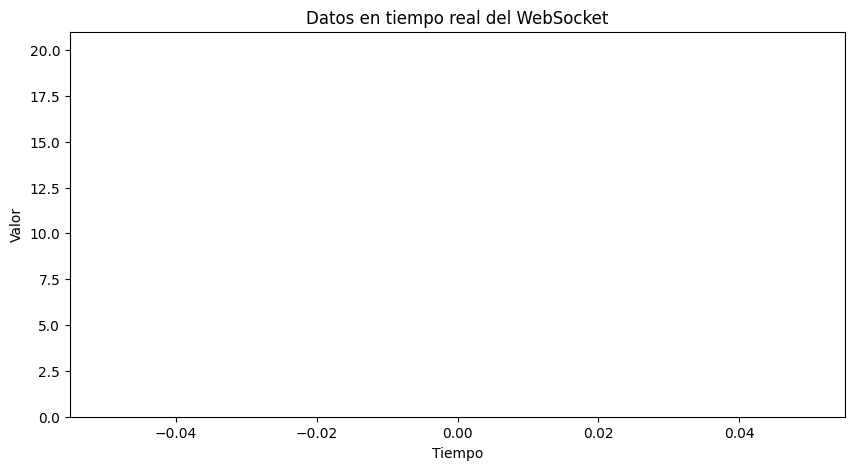

/tmp/ipython-input-2-2702548941.py:49: UserWarning:

frames=None which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.



Servidor WebSocket activo en ws://localhost:8765
Gráfico actualizándose cada 0.5 segundos...


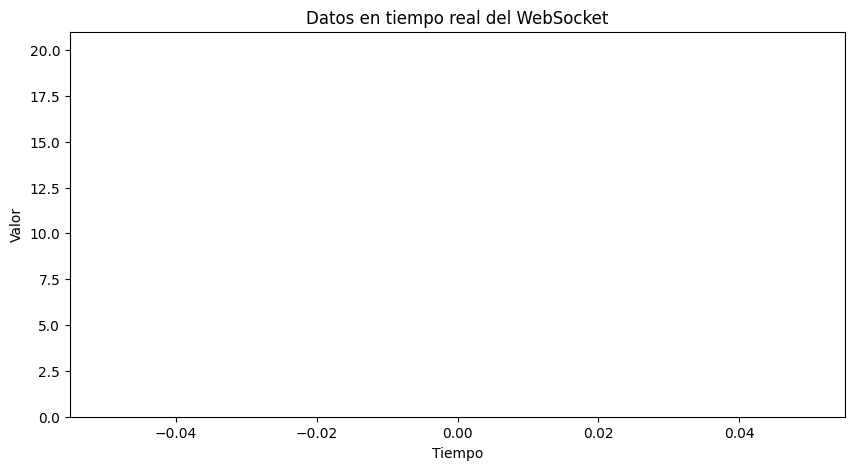

In [ ]:
!pip install websockets matplotlib

import asyncio
import websockets
import json
import random
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import display
import threading

# Configuración del gráfico
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_ylim(0, 21)
ax.set_title('Datos en tiempo real del WebSocket')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Valor')
line, = ax.plot([], [], 'b-')
display(fig)

# Datos compartidos
latest_value = 0
data_buffer = []

# Servidor WebSocket
async def handler(websocket):
    global latest_value
    while True:
        latest_value = random.randint(1, 20)
        await websocket.send(json.dumps({"value": latest_value}))
        await asyncio.sleep(0.5)

async def main():
    async with websockets.serve(handler, "localhost", 8765):
        await asyncio.Future()

# Función de animación
def update(frame):
    global data_buffer
    if latest_value > 0:
        data_buffer.append(latest_value)
        if len(data_buffer) > 20:
            data_buffer = data_buffer[-20:]
        line.set_data(range(len(data_buffer)), data_buffer)
        ax.set_xlim(0, max(20, len(data_buffer)))
    return line,

# Iniciar animación
ani = FuncAnimation(fig, update, interval=200, blit=True)

# Iniciar servidor en segundo plano
thread = threading.Thread(target=lambda: asyncio.run(main()), daemon=True)
thread.start()

print("Servidor WebSocket activo en ws://localhost:8765")
print("Gráfico actualizándose cada 0.5 segundos...")

In [ ]:
async def test_client():
    async with websockets.connect("ws://localhost:8765") as websocket:
        await websocket.send("Hello world!")
        print(await websocket.recv())

await test_client()  # En lugar de asyncio.run(test_client())

{"value": 20}


In [ ]:
import plotly.graph_objs as go
import numpy as np
import random
import time
from IPython.display import display, clear_output

# Datos iniciales
x = []
y = []
colors = {"red": [], "green": [], "blue": []}

# Crear figura con una línea por color
fig = go.Figure()
for color in colors:
    fig.add_trace(go.Scatter(x=[], y=[], mode='lines+markers', name=color.capitalize(), line=dict(color=color)))

# Simular datos como si vinieran de un WebSocket
for i in range(100):  # Simula 100 puntos
    data = {
        "x": random.uniform(-5, 5),
        "y": random.uniform(-5, 5),
        "color": random.choice(["red", "green", "blue"])
    }

    color = data["color"]
    colors[color].append((data["x"], data["y"]))

    # Actualizar cada traza con sus propios datos
    for j, color_key in enumerate(colors):
        xs, ys = zip(*colors[color_key]) if colors[color_key] else ([], [])
        fig.data[j].x = xs
        fig.data[j].y = ys

    clear_output(wait=True)
    display(fig)
    time.sleep(0.5)


KeyboardInterrupt: 